<h2 align="center">CIFAR-10 Classification: CNN vs AlexNet vs VGG vs ResNet</h2>

Same pipeline as the baseline CNN lab. All four models are defined below, then trained one after another with the same `train_and_test()` function.
**Run All** trains every model and ends with a comparison chart.

### 🔁 Recap from the [CNN lab](../12_CNN/CNN_CIFAR10_Classification.ipynb)

| Model | Train Acc | Test Acc |
|---|---|---|
| CNN | 97.7% | 71.9% |
| CNN + BN + Dropout | 83.3% | 75.5% |

- The baseline CNN **overfits**: big train–test gap.
- ~99% of its parameters live in the **FC layers**.
- **BatchNorm** + **Dropout** reduced the gap.

**Today:** how famous architectures (AlexNet, VGG, ResNet) used these same ideas, plus new ones, to go much further.

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import numpy as np

In [28]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

### Data Load

In [29]:
from torchvision.datasets.utils import download_and_extract_archive

# Download the CIFAR-10 archive from an alternative server
download_and_extract_archive(
    url="https://zenodo.org/records/10089977/files/cifar-10-python.tar.gz",
    download_root="./data",
    filename="cifar-10-python.tar.gz",
    md5="c58f30108f718f92721af3b95e74349a",
)

In [30]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [31]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [32]:
batch_size = 100

# Data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Visualize a Few Images

In [33]:
for i, (images, labels) in enumerate(train_loader):
    print(images.shape)
    print(labels.shape)
    break

torch.Size([100, 3, 32, 32])
torch.Size([100])


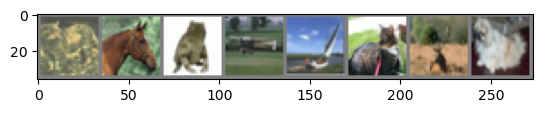

In [34]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
imshow(torchvision.utils.make_grid(images[:8]))

In [35]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

### Model 1 — Baseline CNN

Same model as last lab. Two conv layers: shallow, learns only simple edges/blobs, and the big FC head overfits.

![CIFAR-10 CNN architecture](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/cifar10_cnn.png)

In [36]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=(3,3), padding='same'),  # Output: (32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),        # Output: (32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=(3,3)),             # Output: (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))         # Output: (64, 7, 7)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                                # Flatten to (64 * 7 * 7 = 3136)
            nn.Linear(64 * 7 * 7, 600),                  # Corrected input size
            nn.ReLU(),
            nn.Linear(600, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.network(x)
        x = self.fc_layers(x)
        return x

### Model 2 — AlexNet (CIFAR version)

Deeper (5 conv layers), wider (up to 256-384 channels), and **Dropout** in the FC head to control overfitting (you added Dropout yourself last lab).

> The original AlexNet used 11×11 filters with stride 4 on 224×224 ImageNet images. On 32×32 CIFAR images that would shrink the image to ~7×7 after the first layer, so we use 3×3 filters instead. The key idea (deeper + wider + ReLU + Dropout) stays the same.

![AlexNet (CIFAR-10 version) architecture](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/alexnet_cifar10.png)

In [37]:
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3,3), padding='same'),   # Output: (64, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),         # Output: (64, 16, 16)

            nn.Conv2d(64, 192, kernel_size=(3,3), padding='same'), # Output: (192, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),         # Output: (192, 8, 8)

            nn.Conv2d(192, 384, kernel_size=(3,3), padding='same'),# Output: (384, 8, 8)
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=(3,3), padding='same'),# Output: (256, 8, 8)
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3,3), padding='same'),# Output: (256, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))          # Output: (256, 4, 4)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                                # Flatten to (256 * 4 * 4 = 4096)
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.network(x)
        x = self.fc_layers(x)
        return x

### Model 3 — VGG-style (with BatchNorm)

Only 3×3 convs, stacked uniformly with channels doubling 64→128→256→512, **BatchNorm** for stable training (same as last lab's exercise), and a tiny FC head (just one Linear).

> Two stacked 3×3 convs see the same area as one 5×5 conv but with fewer parameters.
> The original VGG had no BatchNorm (BN came later, in 2015) and a huge 3-layer FC head built for 224×224 images. We keep the core idea: small 3×3 filters, stacked deep.

![VGG-style (CIFAR-10) architecture](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/vgg_cifar10.png)

In [38]:
class VGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3,3), padding='same'),    # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),          # (64, 16, 16)

            nn.Conv2d(64, 128, kernel_size=(3,3), padding='same'),  # (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),          # (128, 8, 8)

            nn.Conv2d(128, 256, kernel_size=(3,3), padding='same'), # (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3,3), padding='same'), # (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),          # (256, 4, 4)

            nn.Conv2d(256, 512, kernel_size=(3,3), padding='same'), # (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3,3), padding='same'), # (512, 4, 4)
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),          # (512, 2, 2)

            nn.Conv2d(512, 512, kernel_size=(3,3), padding='same'), # (512, 2, 2)
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3,3), padding='same'), # (512, 2, 2)
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))           # (512, 1, 1)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                                # Flatten to (512 * 1 * 1 = 512)
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.network(x)
        x = self.fc_layers(x)
        return x

### Model 4 — ResNet-18

Deepest network. The **skip connection** (`out + x`) gives gradients a direct path back, so many layers stay trainable. `BasicBlock` is the repeating unit; `ResNet` stacks it.

> Why skip connections? Just stacking more plain layers makes a network *worse*, even on training data, because the gradient fades as it flows back through many layers. The skip path lets the signal and gradient bypass the block.
> Instead of flattening into a big FC head, ResNet uses **global average pooling** (`AdaptiveAvgPool2d`) → almost no FC parameters.

![ResNet-18 (CIFAR-10 version) architecture](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/resnet18_cifar10.png)

![ResNet BasicBlock](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/resnet_basic_block.png)

In [39]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=(3,3), stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=(3,3), stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU()

        # shortcut path: match shape when channels/size change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=(1,1), stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)     # skip connection
        out = self.relu(out)
        return out

In [40]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3,3), stride=1, padding=1, bias=False),  # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.network = nn.Sequential(
            BasicBlock(64, 64, stride=1),    BasicBlock(64, 64, stride=1),    # (64, 32, 32)
            BasicBlock(64, 128, stride=2),   BasicBlock(128, 128, stride=1),  # (128, 16, 16)
            BasicBlock(128, 256, stride=2),  BasicBlock(256, 256, stride=1),  # (256, 8, 8)
            BasicBlock(256, 512, stride=2),  BasicBlock(512, 512, stride=1)   # (512, 4, 4)
        )
        self.fc_layers = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),                 # (512, 1, 1)
            nn.Flatten(),                                # Flatten to 512
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.network(x)
        x = self.fc_layers(x)
        return x

### Train & Test Function

One function trains a model, tests it on train and test data, and saves the result in `results`.
We call it once for each model below.

In [41]:
!pip install -q torchinfo
from torchinfo import summary

results = {}   # each call to train_and_test() adds one row here

In [42]:
def train_and_test(model, num_epochs=10, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i+1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}")

    # Testing the model (on train and test data)
    model.eval()
    acc = {}
    with torch.no_grad():
        for name, loader in [('train', train_loader), ('test', test_loader)]:
            correct = 0
            total = 0
            for images, labels in loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            acc[name] = 100 * correct / total

    print(f"Train accuracy: {acc['train']:.2f}%")
    print(f"Accuracy of the model on the 10000 test images: {acc['test']:.2f}%")

    # Save this model's result for the final comparison
    results[type(model).__name__] = {'Train Acc': acc['train'], 'Test Acc': acc['test']}
    return acc

### Train 1 — CNN

In [43]:
model = CNN().to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 3136]                 --
│    └─Linear: 2-8                       [1, 600]                  1,882,200
│    └─ReLU: 2-9                         [1, 600]                  --
│    └─Linear: 2-10                      [1, 120]                  72,120

In [44]:
train_and_test(model)

Epoch [1/10], Step [100/500], Loss: 1.6083
Epoch [1/10], Step [200/500], Loss: 1.3382
Epoch [1/10], Step [300/500], Loss: 1.2761
Epoch [1/10], Step [400/500], Loss: 1.2830
Epoch [1/10], Step [500/500], Loss: 0.9975
Epoch [2/10], Step [100/500], Loss: 1.0956
Epoch [2/10], Step [200/500], Loss: 0.8775
Epoch [2/10], Step [300/500], Loss: 1.0134
Epoch [2/10], Step [400/500], Loss: 1.0059
Epoch [2/10], Step [500/500], Loss: 0.8668
Epoch [3/10], Step [100/500], Loss: 0.6991
Epoch [3/10], Step [200/500], Loss: 0.8224
Epoch [3/10], Step [300/500], Loss: 0.7003
Epoch [3/10], Step [400/500], Loss: 0.7441
Epoch [3/10], Step [500/500], Loss: 0.6877
Epoch [4/10], Step [100/500], Loss: 0.6896
Epoch [4/10], Step [200/500], Loss: 0.6061
Epoch [4/10], Step [300/500], Loss: 0.5862
Epoch [4/10], Step [400/500], Loss: 0.7290
Epoch [4/10], Step [500/500], Loss: 0.6471
Epoch [5/10], Step [100/500], Loss: 0.4610
Epoch [5/10], Step [200/500], Loss: 0.4379
Epoch [5/10], Step [300/500], Loss: 0.3580
Epoch [5/10

{'train': 97.116, 'test': 72.31}

### Train 2 — AlexNet

In [45]:
model = AlexNet().to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 256, 4, 4]            --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           1,792
│    └─ReLU: 2-2                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 192, 16, 16]          110,784
│    └─ReLU: 2-5                         [1, 192, 16, 16]          --
│    └─MaxPool2d: 2-6                    [1, 192, 8, 8]            --
│    └─Conv2d: 2-7                       [1, 384, 8, 8]            663,936
│    └─ReLU: 2-8                         [1, 384, 8, 8]            --
│    └─Conv2d: 2-9                       [1, 256, 8, 8]            884,992
│    └─ReLU: 2-10                        [1, 256, 8, 8]            --
│    └─Conv2d: 2-11                      [1, 256, 8, 8]            

In [46]:
train_and_test(model)

Epoch [1/10], Step [100/500], Loss: 1.8422
Epoch [1/10], Step [200/500], Loss: 1.7378
Epoch [1/10], Step [300/500], Loss: 1.4768
Epoch [1/10], Step [400/500], Loss: 1.4492
Epoch [1/10], Step [500/500], Loss: 1.2622
Epoch [2/10], Step [100/500], Loss: 1.1621
Epoch [2/10], Step [200/500], Loss: 1.0253
Epoch [2/10], Step [300/500], Loss: 1.2215
Epoch [2/10], Step [400/500], Loss: 0.9863
Epoch [2/10], Step [500/500], Loss: 0.9594
Epoch [3/10], Step [100/500], Loss: 1.1110
Epoch [3/10], Step [200/500], Loss: 0.9040
Epoch [3/10], Step [300/500], Loss: 1.0659
Epoch [3/10], Step [400/500], Loss: 0.8409
Epoch [3/10], Step [500/500], Loss: 1.2519
Epoch [4/10], Step [100/500], Loss: 0.9879
Epoch [4/10], Step [200/500], Loss: 0.7738
Epoch [4/10], Step [300/500], Loss: 1.0161
Epoch [4/10], Step [400/500], Loss: 0.9509
Epoch [4/10], Step [500/500], Loss: 0.8971
Epoch [5/10], Step [100/500], Loss: 0.6554
Epoch [5/10], Step [200/500], Loss: 0.7132
Epoch [5/10], Step [300/500], Loss: 0.9040
Epoch [5/10

{'train': 88.732, 'test': 77.53}

### Train 3 — VGG

In [47]:
model = VGG().to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 512, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 16, 16]          256
│    └─ReLU: 2-7                         [1, 128, 16, 16]          --
│    └─MaxPool2d: 2-8                    [1, 128, 8, 8]            --
│    └─Conv2d: 2-9                       [1, 256, 8, 8]            295,168
│    └─BatchNorm2d: 2-10                 [1, 256, 8, 8]            512
│    └─ReLU: 2-11                        [1, 256, 8, 8]            --


In [48]:
train_and_test(model)

Epoch [1/10], Step [100/500], Loss: 1.6249
Epoch [1/10], Step [200/500], Loss: 1.1498
Epoch [1/10], Step [300/500], Loss: 1.2985
Epoch [1/10], Step [400/500], Loss: 0.9277
Epoch [1/10], Step [500/500], Loss: 0.8893
Epoch [2/10], Step [100/500], Loss: 0.9410
Epoch [2/10], Step [200/500], Loss: 0.6231
Epoch [2/10], Step [300/500], Loss: 0.7291
Epoch [2/10], Step [400/500], Loss: 0.7952
Epoch [2/10], Step [500/500], Loss: 0.6621
Epoch [3/10], Step [100/500], Loss: 0.5467
Epoch [3/10], Step [200/500], Loss: 0.5049
Epoch [3/10], Step [300/500], Loss: 0.6300
Epoch [3/10], Step [400/500], Loss: 0.5184
Epoch [3/10], Step [500/500], Loss: 0.6523
Epoch [4/10], Step [100/500], Loss: 0.4070
Epoch [4/10], Step [200/500], Loss: 0.4173
Epoch [4/10], Step [300/500], Loss: 0.5424
Epoch [4/10], Step [400/500], Loss: 0.5082
Epoch [4/10], Step [500/500], Loss: 0.4785
Epoch [5/10], Step [100/500], Loss: 0.2804
Epoch [5/10], Step [200/500], Loss: 0.5420
Epoch [5/10], Step [300/500], Loss: 0.5464
Epoch [5/10

{'train': 97.93, 'test': 82.56}

### Train 4 — ResNet

In [49]:
model = ResNet().to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           1,728
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           --
├─Sequential: 1-2                        [1, 512, 4, 4]            --
│    └─BasicBlock: 2-4                   [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           128
│    │    └─ReLU: 3-3                    [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           128
│    │    └─Sequential: 3-6              [1, 64, 32, 32]           --
│

In [50]:
train_and_test(model)

Epoch [1/10], Step [100/500], Loss: 1.6231
Epoch [1/10], Step [200/500], Loss: 1.5097
Epoch [1/10], Step [300/500], Loss: 1.0939
Epoch [1/10], Step [400/500], Loss: 1.3037
Epoch [1/10], Step [500/500], Loss: 1.3621
Epoch [2/10], Step [100/500], Loss: 1.1548
Epoch [2/10], Step [200/500], Loss: 0.7931
Epoch [2/10], Step [300/500], Loss: 0.9884
Epoch [2/10], Step [400/500], Loss: 0.7164
Epoch [2/10], Step [500/500], Loss: 0.7865
Epoch [3/10], Step [100/500], Loss: 0.7358
Epoch [3/10], Step [200/500], Loss: 0.5410
Epoch [3/10], Step [300/500], Loss: 0.6599
Epoch [3/10], Step [400/500], Loss: 0.6105
Epoch [3/10], Step [500/500], Loss: 0.6902
Epoch [4/10], Step [100/500], Loss: 0.4619
Epoch [4/10], Step [200/500], Loss: 0.7059
Epoch [4/10], Step [300/500], Loss: 0.3600
Epoch [4/10], Step [400/500], Loss: 0.3900
Epoch [4/10], Step [500/500], Loss: 0.4049
Epoch [5/10], Step [100/500], Loss: 0.3792
Epoch [5/10], Step [200/500], Loss: 0.3217
Epoch [5/10], Step [300/500], Loss: 0.2452
Epoch [5/10

{'train': 97.674, 'test': 82.85}

### Comparison

         Train Acc  Test Acc
CNN          97.12     72.31
AlexNet      88.73     77.53
VGG          97.93     82.56
ResNet       97.67     82.85


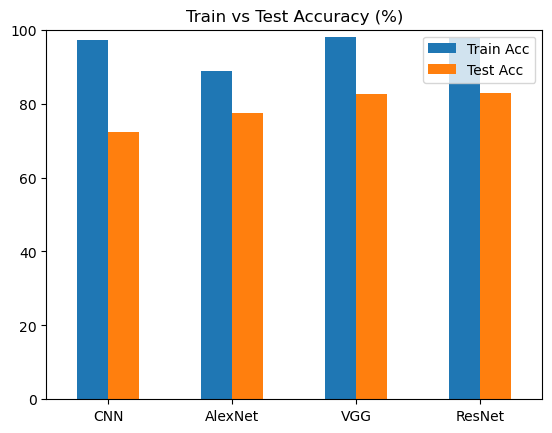

In [51]:
import pandas as pd

df = pd.DataFrame(results).T
print(df.round(2))
df.plot.bar(rot=0, ylim=(0, 100), title='Train vs Test Accuracy (%)')
plt.show()

### ✅ Conclusion

| Model | Total params | FC params | Idea |
|---|---|---|---|
| CNN | 1.97M | 1.96M (99%) | 2 convs + big FC head |
| AlexNet | 35.9M | 33.6M (94%) | deeper + wider + Dropout |
| VGG-style | 9.2M | 0.005M | stacked 3×3 convs + BatchNorm |
| ResNet-18 | 11.2M | 0.005M | skip connections + global avg pool |

- **AlexNet:** deeper + wider + Dropout. Better features, but most parameters still sit in a huge FC head.
- **VGG:** only 3×3 convs + BatchNorm. Parameters move into the conv layers; tiny FC head.
- **ResNet:** skip connections (`out + x`) let very deep networks train; global average pooling replaces the big FC head.
- **Trend:** parameters move from FC layers into conv layers, networks get deeper, and test accuracy goes up.

### References

1. Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. *Advances in Neural Information Processing Systems 25*, 1097–1105.
2. Simonyan, K., & Zisserman, A. (2015). Very deep convolutional networks for large-scale image recognition. *ICLR*. [arXiv:1409.1556](https://arxiv.org/abs/1409.1556)
3. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*, 770–778. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)
4. Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*. [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)
5. Krizhevsky, A. (2009). *Learning multiple layers of features from tiny images* (Technical report). University of Toronto. — the CIFAR-10 dataset.